# Output BAB 4.5 - Evaluasi Akhir Model

Notebook ini menghasilkan artefak tabel, grafik, dan narasi untuk subbab 4.5 Evaluasi Akhir Model pada wilayah uji Aceh_Utara.

## 0. Setup

Konfigurasi path, folder output, plotting style, dan helper toleran. Jika artefak belum tersedia, notebook membuat tabel status/warning dan tetap lanjut.


In [2]:
from __future__ import annotations

import json
import math
import re
from collections import Counter, defaultdict
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    import rasterio
except Exception as exc:
    rasterio = None
    RASTERIO_IMPORT_ERROR = f"{type(exc).__name__}: {exc}"
else:
    RASTERIO_IMPORT_ERROR = ""

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "font.size": 10,
})

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATASET = ROOT / "dataset"
RUNS = ROOT / "runs"
OUT = ROOT / "outputs" / "bab4"
TABLE_DIR = OUT / "tables"
FIG_DIR = OUT / "figures"
NARRATIVE_DIR = OUT / "narratives"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
NARRATIVE_DIR.mkdir(parents=True, exist_ok=True)

REGIONS = [
    "Aceh_Besar", "Aceh_Tamiang", "Aceh_Timur", "Aceh_Utara", "Agam",
    "Banda_Aceh", "Bireuen", "Langsa", "Pasaman_Barat", "Pidie", "Pidie_Jaya",
]
TEST_REGION = "Aceh_Utara"
CHANNEL_NAMES = ["vv_norm", "vh_norm", "hue", "saturation", "value", "slope_norm", "hand_norm"]

print(f"ROOT: {ROOT}")
print(f"Tables: {TABLE_DIR}")
print(f"Figures: {FIG_DIR}")
print("rasterio:", "available" if rasterio else f"missing ({RASTERIO_IMPORT_ERROR})")


ROOT: /home/nozomi/Productive/skripsi
Tables: /home/nozomi/Productive/skripsi/outputs/bab4/tables
Figures: /home/nozomi/Productive/skripsi/outputs/bab4/figures
rasterio: available


In [3]:
def display_df(df: pd.DataFrame, max_rows: int = 20):
    if df.empty:
        display(df)
    else:
        display(df.head(max_rows))


def save_table(df: pd.DataFrame, name: str) -> Path:
    path = TABLE_DIR / name
    df.to_csv(path, index=False)
    print(f"saved table: {path.relative_to(ROOT)} ({len(df)} rows)")
    display_df(df)
    return path


def save_fig(fig, name: str) -> Path:
    path = FIG_DIR / name
    try:
        fig.tight_layout(rect=[0, 0, 1, 0.96])
    except Exception:
        fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    print(f"saved figure: {path.relative_to(ROOT)}")
    plt.show()
    return path


def read_csv_or_status(path: Path, label: str) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame([{"source": str(path.relative_to(ROOT)), "status": "missing", "note": label}])
    try:
        return pd.read_csv(path)
    except Exception as exc:
        return pd.DataFrame([{"source": str(path.relative_to(ROOT)), "status": "read_error", "note": f"{type(exc).__name__}: {exc}"}])


def safe_div(num: float, den: float) -> float:
    return float(num / den) if den else 0.0


def pct(num: float, den: float) -> float:
    return round(100.0 * safe_div(num, den), 4)


def finite_stats(arr: np.ndarray, sample_step: int = 1) -> dict:
    a = np.asarray(arr)
    if sample_step > 1 and a.ndim >= 2:
        a = a[..., ::sample_step, ::sample_step]
    a = a.astype("float64", copy=False)
    finite = np.isfinite(a)
    vals = a[finite]
    if vals.size == 0:
        return {"count": 0, "valid_pct": 0.0, "min": np.nan, "max": np.nan, "mean": np.nan, "std": np.nan, "p2": np.nan, "p98": np.nan}
    return {
        "count": int(vals.size),
        "valid_pct": round(100.0 * vals.size / a.size, 4),
        "min": float(np.min(vals)),
        "max": float(np.max(vals)),
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals)),
        "p2": float(np.percentile(vals, 2)),
        "p98": float(np.percentile(vals, 98)),
    }


def normalize_image(arr: np.ndarray, p_low: float = 2, p_high: float = 98) -> np.ndarray:
    a = np.asarray(arr, dtype="float32")
    finite = np.isfinite(a)
    if not finite.any():
        return np.zeros_like(a, dtype="float32")
    lo, hi = np.percentile(a[finite], [p_low, p_high])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = float(np.nanmin(a[finite])), float(np.nanmax(a[finite]))
    if hi <= lo:
        return np.zeros_like(a, dtype="float32")
    return np.clip((a - lo) / (hi - lo), 0, 1)


def raster_stats(path: Path, band: int = 1, sample_step: int = 10) -> dict:
    if rasterio is None:
        return {"status": "skipped", "note": f"rasterio unavailable: {RASTERIO_IMPORT_ERROR}"}
    if not path.exists():
        return {"status": "missing", "note": str(path.relative_to(ROOT))}
    try:
        with rasterio.open(path) as src:
            arr = src.read(band, masked=True)
            vals = arr.compressed() if np.ma.isMaskedArray(arr) else np.asarray(arr).ravel()
            if sample_step > 1:
                arr2 = np.asarray(arr.filled(np.nan) if np.ma.isMaskedArray(arr) else arr)
                vals = arr2[::sample_step, ::sample_step].ravel()
            stats = finite_stats(vals)
            stats.update({
                "status": "ok",
                "height": src.height,
                "width": src.width,
                "crs": str(src.crs),
                "transform": str(src.transform),
            })
            return stats
    except Exception as exc:
        return {"status": "read_error", "note": f"{type(exc).__name__}: {exc}"}


def load_npz(path: Path):
    return np.load(path, allow_pickle=False)


def first_npz(path: Path) -> Path | None:
    files = sorted(path.glob("*.npz"))
    return files[0] if files else None


def parse_tile_rc(path: Path) -> tuple[int | None, int | None]:
    m = re.search(r"_r(\d+)_c(\d+)", path.stem)
    if not m:
        return None, None
    return int(m.group(1)), int(m.group(2))


def choose_tile(region: str = TEST_REGION) -> Path | None:
    tile_dir = DATASET / "tiles" / "7ch" / "by_region" / region
    candidates = []
    for path in sorted(tile_dir.glob("*.npz")):
        try:
            z = load_npz(path)
            y = np.asarray(z["y"])[0]
            valid = np.asarray(z.get("valid_mask", np.ones_like(y)))[0]
            positives = int(((y > 0) & (valid > 0)).sum())
            valid_count = int((valid > 0).sum())
            candidates.append((positives, valid_count, path))
        except Exception:
            continue
    if not candidates:
        return None
    positives = [c for c in candidates if c[0] > 0]
    if positives:
        return sorted(positives, key=lambda x: x[0], reverse=True)[0][2]
    return sorted(candidates, key=lambda x: x[1], reverse=True)[0][2]


def find_matching_prediction(model: str, tile_path: Path) -> Path | None:
    pred_dir = RUNS / "final" / model / "eval_test" / "predictions" / TEST_REGION
    candidate = pred_dir / tile_path.name
    if candidate.exists():
        return candidate
    r, c = parse_tile_rc(tile_path)
    if r is None:
        return first_npz(pred_dir)
    matches = sorted(pred_dir.glob(f"*r{r:06d}_c{c:06d}.npz"))
    return matches[0] if matches else first_npz(pred_dir)


## 4.5 Evaluasi Akhir Model pada Wilayah Uji Aceh_Utara

Sumber utama adalah `runs/final/unet/eval_test/metrics.csv` dan `runs/final/procanet/eval_test/metrics.csv`. Precision dan recall dihitung ulang dari confusion matrix piksel agar konsisten dengan TP, FP, dan FN.

In [4]:
MODEL_ORDER = ['unet', 'procanet']
MODEL_LABELS = {'unet': 'U-Net', 'procanet': 'ProCANet'}


def read_final_metric_record(model: str) -> dict:
    csv_path = RUNS / 'final' / model / 'eval_test' / 'metrics.csv'
    json_path = RUNS / 'final' / model / 'eval_test' / 'metrics.json'
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        row = df[df.get('region', '') == TEST_REGION].head(1)
        if row.empty:
            row = df[df.get('region', '') == 'aggregate'].head(1)
        if row.empty:
            row = df.head(1)
        rec = row.iloc[0].to_dict() if not row.empty else {}
        source = csv_path
    elif json_path.exists():
        data = json.loads(json_path.read_text())
        rec = data.get('metrics', data)
        source = json_path
    else:
        rec = {'status': 'missing'}
        source = None
    rec['model_key'] = model
    rec['model'] = MODEL_LABELS[model]
    rec['source'] = str(source.relative_to(ROOT)) if source else 'missing'
    return rec

records = [read_final_metric_record(model) for model in MODEL_ORDER]

metric_rows = []
conf_rows = []
for rec in records:
    tp = float(rec.get('tp', np.nan))
    tn = float(rec.get('tn', np.nan))
    fp = float(rec.get('fp', np.nan))
    fn = float(rec.get('fn', np.nan))
    total = tp + tn + fp + fn if np.isfinite([tp, tn, fp, fn]).all() else np.nan
    precision = safe_div(tp, tp + fp) if np.isfinite(tp + fp) else np.nan
    recall = safe_div(tp, tp + fn) if np.isfinite(tp + fn) else np.nan
    specificity = safe_div(tn, tn + fp) if np.isfinite(tn + fp) else np.nan
    fpr = safe_div(fp, fp + tn) if np.isfinite(fp + tn) else np.nan
    fnr = safe_div(fn, fn + tp) if np.isfinite(fn + tp) else np.nan
    flood_prevalence = safe_div(tp + fn, total) if np.isfinite(total) else np.nan
    metric_rows.append({
        'model': rec['model'],
        'model_key': rec['model_key'],
        'region': rec.get('region', TEST_REGION),
        'loss': rec.get('loss', np.nan),
        'iou': rec.get('iou', rec.get('jaccard', np.nan)),
        'dice_f1': rec.get('dice', rec.get('f1', np.nan)),
        'accuracy': rec.get('accuracy', np.nan),
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'flood_pixel_prevalence': flood_prevalence,
        'source': rec['source'],
        'status': rec.get('status', 'ok'),
    })
    conf_rows.append({
        'model': rec['model'],
        'model_key': rec['model_key'],
        'region': rec.get('region', TEST_REGION),
        'tp': int(tp) if np.isfinite(tp) else np.nan,
        'tn': int(tn) if np.isfinite(tn) else np.nan,
        'fp': int(fp) if np.isfinite(fp) else np.nan,
        'fn': int(fn) if np.isfinite(fn) else np.nan,
        'precision': precision,
        'recall': recall,
        'false_positive_rate': fpr,
        'false_negative_rate': fnr,
        'status': rec.get('status', 'ok'),
    })

final_metrics = pd.DataFrame(metric_rows)
confusion = pd.DataFrame(conf_rows)

# Add a concise interpretation column after all models are loaded.
best_iou = final_metrics.loc[final_metrics['iou'].astype(float).idxmax(), 'model'] if final_metrics['iou'].notna().any() else ''
best_dice = final_metrics.loc[final_metrics['dice_f1'].astype(float).idxmax(), 'model'] if final_metrics['dice_f1'].notna().any() else ''
best_precision = final_metrics.loc[final_metrics['precision'].astype(float).idxmax(), 'model'] if final_metrics['precision'].notna().any() else ''
best_recall = final_metrics.loc[final_metrics['recall'].astype(float).idxmax(), 'model'] if final_metrics['recall'].notna().any() else ''

def metric_note(row):
    parts = []
    if row['model'] == best_iou:
        parts.append('IoU tertinggi')
    if row['model'] == best_dice:
        parts.append('Dice/F1 tertinggi')
    if row['model'] == best_precision:
        parts.append('precision tertinggi')
    if row['model'] == best_recall:
        parts.append('recall tertinggi')
    return '; '.join(parts) if parts else 'performa relatif lebih rendah pada metrik utama'

final_metrics['interpretasi_singkat'] = final_metrics.apply(metric_note, axis=1)

save_table(final_metrics, '4_5_final_metrics.csv')
save_table(confusion, '4_5_confusion_matrix_pixels.csv')


saved table: outputs/bab4/tables/4_5_final_metrics.csv (2 rows)


,model,model_key,region,loss,iou,dice_f1,accuracy,precision,recall,specificity,flood_pixel_prevalence,source,status,interpretasi_singkat
0,U-Net,unet,Aceh_Utara,0.604995,0.850992,0.919498,0.970733,0.932163,0.907173,0.985089,0.184246,runs/final/unet/eval_test/metrics.csv,ok,IoU tertinggi; Dice/F1 tertinggi; recall terti...
1,ProCANet,procanet,Aceh_Utara,0.628500,0.838298,0.912037,0.968751,0.947347,0.879264,0.988963,0.184246,runs/final/procanet/eval_test/metrics.csv,ok,precision tertinggi


saved table: outputs/bab4/tables/4_5_confusion_matrix_pixels.csv (2 rows)


,model,model_key,region,tp,tn,fp,fn,precision,recall,false_positive_rate,false_negative_rate,status
0,U-Net,unet,Aceh_Utara,16863330,81075762,1227212,1725554,0.932163,0.907173,0.014911,0.092827,ok
1,ProCANet,procanet,Aceh_Utara,16344540,81394556,908418,2244344,0.947347,0.879264,0.011037,0.120736,ok


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_5_confusion_matrix_pixels.csv')

saved figure: outputs/bab4/figures/4_5_final_metrics_comparison.png


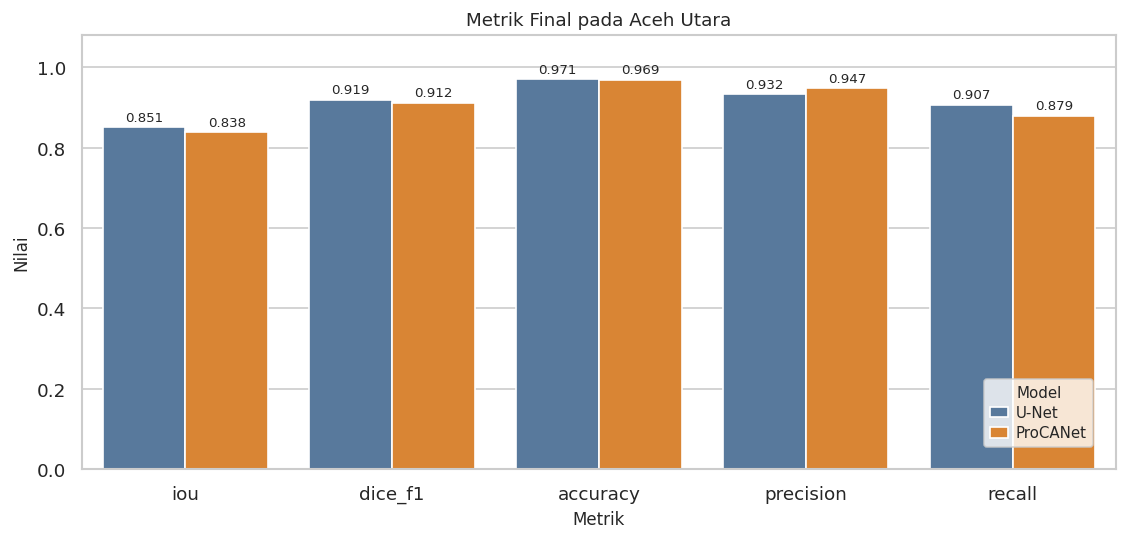

PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/figures/4_5_final_metrics_comparison.png')

In [15]:
fig, ax = plt.subplots(figsize=(9.5, 4.8))

metric_cols = ['iou', 'dice_f1', 'accuracy', 'precision', 'recall']
plot_df = final_metrics.melt(
    id_vars=['model'],
    value_vars=[c for c in metric_cols if c in final_metrics.columns],
    var_name='metric',
    value_name='value',
)

plot_df = plot_df[np.isfinite(plot_df['value'])]

if plot_df.empty:
    ax.text(0.5, 0.5, 'Final metrics unavailable', ha='center', va='center')
    ax.axis('off')

else:
    sns.barplot(
        data=plot_df,
        x='metric',
        y='value',
        hue='model',
        ax=ax,
        palette=['#4C78A8', '#F58518']
    )

    ax.set_ylim(0, 1.08)
    ax.set_xlabel('Metrik')
    ax.set_ylabel('Nilai')
    ax.set_title('Metrik Final pada Aceh Utara')

    # Legend dipindahkan ke dalam area figure
    ax.legend(
        title='Model',
        loc='lower right',
        bbox_to_anchor=(0.985, 0.035),
        frameon=True,
        fontsize=9,
        title_fontsize=9,
        borderpad=0.4,
        labelspacing=0.35,
        handlelength=1.2,
        handletextpad=0.5
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.3f',
            padding=2,
            fontsize=8
        )

    # Sedikit rapikan margin agar tidak boros ruang
    fig.tight_layout()

save_fig(fig, '4_5_final_metrics_comparison.png')

saved table: outputs/bab4/tables/4_5_error_tradeoff_summary.csv (2 rows)


,model,fp,fn,total_error_pixels,dominant_absolute_error,relative_error_character,fp_to_fn_ratio,fp_per_tp,fn_per_tp
0,U-Net,1227212,1725554,2952766,FN lebih banyak daripada FP,coverage lebih luas relatif; FN lebih rendah d...,0.711199,0.072774,0.102326
1,ProCANet,908418,2244344,3152762,FN lebih banyak daripada FP,lebih konservatif relatif; FP lebih rendah dan...,0.404759,0.055579,0.137315


saved figure: outputs/bab4/figures/4_5_fp_fn_bar_chart.png


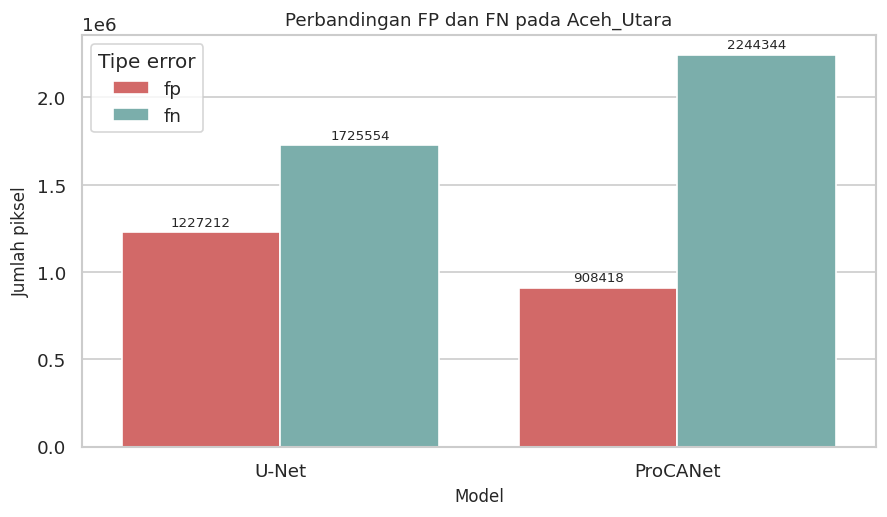

PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/figures/4_5_fp_fn_bar_chart.png')

In [5]:
error_rows = []
min_fp_model = confusion.loc[confusion['fp'].astype(float).idxmin(), 'model']
min_fn_model = confusion.loc[confusion['fn'].astype(float).idxmin(), 'model']
max_precision_model = confusion.loc[confusion['precision'].astype(float).idxmax(), 'model']
max_recall_model = confusion.loc[confusion['recall'].astype(float).idxmax(), 'model']

for _, row in confusion.iterrows():
    tp = float(row['tp'])
    fp = float(row['fp'])
    fn = float(row['fn'])
    if row['model'] == min_fp_model and row['model'] == max_precision_model:
        relative_character = 'lebih konservatif relatif; FP lebih rendah dan precision lebih tinggi'
    elif row['model'] == min_fn_model and row['model'] == max_recall_model:
        relative_character = 'coverage lebih luas relatif; FN lebih rendah dan recall lebih tinggi'
    else:
        relative_character = 'karakter campuran'
    error_rows.append({
        'model': row['model'],
        'fp': int(fp),
        'fn': int(fn),
        'total_error_pixels': int(fp + fn),
        'dominant_absolute_error': 'FN lebih banyak daripada FP' if fn > fp else 'FP lebih banyak daripada FN',
        'relative_error_character': relative_character,
        'fp_to_fn_ratio': safe_div(fp, fn),
        'fp_per_tp': safe_div(fp, tp),
        'fn_per_tp': safe_div(fn, tp),
    })
error_tradeoff = pd.DataFrame(error_rows)
save_table(error_tradeoff, '4_5_error_tradeoff_summary.csv')

fig, ax = plt.subplots(figsize=(7.5, 4.6))
err_plot = error_tradeoff.melt(id_vars=['model'], value_vars=['fp', 'fn'], var_name='error_type', value_name='pixel_count')
sns.barplot(data=err_plot, x='model', y='pixel_count', hue='error_type', ax=ax, palette=['#E45756', '#72B7B2'])
ax.set_title('Perbandingan FP dan FN pada Aceh_Utara')
ax.set_xlabel('Model')
ax.set_ylabel('Jumlah piksel')
ax.legend(title='Tipe error')
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=2, fontsize=8)
save_fig(fig, '4_5_fp_fn_bar_chart.png')


In [6]:
u = final_metrics.set_index('model').loc['U-Net']
p = final_metrics.set_index('model').loc['ProCANet']
uc = confusion.set_index('model').loc['U-Net']
pc = confusion.set_index('model').loc['ProCANet']

lines = [
    '# Interpretasi Evaluasi Akhir 4.5',
    '',
    f"Evaluasi akhir dilakukan pada wilayah uji independen {TEST_REGION}. Tabel metrik menunjukkan U-Net memperoleh IoU {u['iou']:.4f} dan Dice/F1 {u['dice_f1']:.4f}, sedangkan ProCANet memperoleh IoU {p['iou']:.4f} dan Dice/F1 {p['dice_f1']:.4f}. Dengan demikian, U-Net memiliki tumpang tindih spasial yang sedikit lebih tinggi terhadap label UNOSAT pada pengujian final.",
    '',
    f"Akurasi kedua model tinggi, yaitu {u['accuracy']:.4f} untuk U-Net dan {p['accuracy']:.4f} untuk ProCANet. Nilai ini perlu dibaca sebagai metrik pelengkap karena piksel non-banjir dominan pada area evaluasi; IoU, Dice/F1, precision, recall, serta FP/FN lebih informatif untuk melihat kualitas segmentasi banjir.",
    '',
    f"Dari confusion matrix, U-Net menghasilkan FP {int(uc['fp']):,} dan FN {int(uc['fn']):,}, sedangkan ProCANet menghasilkan FP {int(pc['fp']):,} dan FN {int(pc['fn']):,}. ProCANet memiliki precision lebih tinggi ({p['precision']:.4f} berbanding {u['precision']:.4f}) karena FP lebih rendah, tetapi recall lebih rendah ({p['recall']:.4f} berbanding {u['recall']:.4f}) karena FN lebih tinggi.",
    '',
    'Pola tersebut menunjukkan trade-off karakter kesalahan. U-Net lebih kuat untuk cakupan banjir karena recall dan overlap lebih tinggi, sementara ProCANet lebih konservatif karena menekan prediksi banjir palsu tetapi lebih sering melewatkan piksel banjir. Kesimpulan 4.5 sebaiknya tidak hanya menyebut model dengan angka tertinggi, tetapi juga menjelaskan risiko operasional dari FP dan FN.',
]

narrative_path = NARRATIVE_DIR / '4_5_final_evaluation_interpretation.md'
narrative_path.write_text('\n'.join(lines) + '\n')
print(f'saved narrative: {narrative_path.relative_to(ROOT)}')
print('\n'.join(lines))


saved narrative: outputs/bab4/narratives/4_5_final_evaluation_interpretation.md
# Interpretasi Evaluasi Akhir 4.5

Evaluasi akhir dilakukan pada wilayah uji independen Aceh_Utara. Tabel metrik menunjukkan U-Net memperoleh IoU 0.8510 dan Dice/F1 0.9195, sedangkan ProCANet memperoleh IoU 0.8383 dan Dice/F1 0.9120. Dengan demikian, U-Net memiliki tumpang tindih spasial yang sedikit lebih tinggi terhadap label UNOSAT pada pengujian final.

Akurasi kedua model tinggi, yaitu 0.9707 untuk U-Net dan 0.9688 untuk ProCANet. Nilai ini perlu dibaca sebagai metrik pelengkap karena piksel non-banjir dominan pada area evaluasi; IoU, Dice/F1, precision, recall, serta FP/FN lebih informatif untuk melihat kualitas segmentasi banjir.

Dari confusion matrix, U-Net menghasilkan FP 1,227,212 dan FN 1,725,554, sedangkan ProCANet menghasilkan FP 908,418 dan FN 2,244,344. ProCANet memiliki precision lebih tinggi (0.9473 berbanding 0.9322) karena FP lebih rendah, tetapi recall lebih rendah (0.8793 berbanding 0.

In [7]:
expected = [
    ('wajib', 'Tabel metrik final U-Net vs ProCANet', TABLE_DIR / '4_5_final_metrics.csv'),
    ('wajib', 'Tabel confusion matrix piksel', TABLE_DIR / '4_5_confusion_matrix_pixels.csv'),
    ('wajib', 'Precision dan recall dari TP/FP/FN', TABLE_DIR / '4_5_final_metrics.csv'),
    ('opsional', 'Bar chart FP/FN', FIG_DIR / '4_5_fp_fn_bar_chart.png'),
    ('disarankan', 'Grafik perbandingan metrik final', FIG_DIR / '4_5_final_metrics_comparison.png'),
    ('disarankan', 'Tabel ringkasan trade-off FP/FN', TABLE_DIR / '4_5_error_tradeoff_summary.csv'),
    ('narasi_wajib', 'Interpretasi IoU dan Dice sebagai metrik utama', NARRATIVE_DIR / '4_5_final_evaluation_interpretation.md'),
    ('narasi_wajib', 'Interpretasi FP/FN sebagai karakter kesalahan model', NARRATIVE_DIR / '4_5_final_evaluation_interpretation.md'),
    ('narasi_wajib', 'Posisi akurasi sebagai metrik pelengkap', NARRATIVE_DIR / '4_5_final_evaluation_interpretation.md'),
]
coverage = pd.DataFrame([
    {
        'priority': priority,
        'todo_item': item,
        'artifact': str(path.relative_to(ROOT)),
        'exists': path.exists(),
        'size_bytes': path.stat().st_size if path.exists() else 0,
    }
    for priority, item, path in expected
])
save_table(coverage, '4_5_todo_coverage_checklist.csv')
missing = coverage[~coverage['exists']]
if missing.empty:
    print('All 4.5 checklist artifacts are available.')
else:
    display(missing)


saved table: outputs/bab4/tables/4_5_todo_coverage_checklist.csv (9 rows)


,priority,todo_item,artifact,exists,size_bytes
0,wajib,Tabel metrik final U-Net vs ProCANet,outputs/bab4/tables/4_5_final_metrics.csv,True,649
1,wajib,Tabel confusion matrix piksel,outputs/bab4/tables/4_5_confusion_matrix_pixel...,True,381
2,wajib,Precision dan recall dari TP/FP/FN,outputs/bab4/tables/4_5_final_metrics.csv,True,649
3,opsional,Bar chart FP/FN,outputs/bab4/figures/4_5_fp_fn_bar_chart.png,True,74487
4,disarankan,Grafik perbandingan metrik final,outputs/bab4/figures/4_5_final_metrics_compari...,True,96411
5,disarankan,Tabel ringkasan trade-off FP/FN,outputs/bab4/tables/4_5_error_tradeoff_summary...,True,490
6,narasi_wajib,Interpretasi IoU dan Dice sebagai metrik utama,outputs/bab4/narratives/4_5_final_evaluation_i...,True,1340
7,narasi_wajib,Interpretasi FP/FN sebagai karakter kesalahan ...,outputs/bab4/narratives/4_5_final_evaluation_i...,True,1340
8,narasi_wajib,Posisi akurasi sebagai metrik pelengkap,outputs/bab4/narratives/4_5_final_evaluation_i...,True,1340


All 4.5 checklist artifacts are available.
